# Session 7 - From Notebook to Research Project

**Course:** Machine Learning in Geoscience - A Project-Based Course  
**Project:** Wind-speed forecasting at Abali  
**Session length:** 90 minutes  
**Data source (the only one used):** `data/raw/abali.xlsx`

---

## Learning objectives

By the end of this session you will be able to:

1. Assemble the whole project - cleaning, features, validation, model selection, evaluation - into **one reproducible pipeline** that runs top to bottom in memory.
2. Select a final model **per horizon** using validation evidence only, and write down the selection rule before looking at the test block.
3. Perform **one** evaluation on the untouched test block, with the baselines in the same table, and compare it honestly with the validation result.
4. Serialise a fitted model **in memory** and prove that the reloaded model predicts identically - a reproducibility check that writes no files.
5. Structure a geoscience machine-learning report: what belongs in each section, which figures a reader expects, and how to state limitations.
6. Present the work in one slide and survive the four questions every reviewer asks.

## Prerequisites

Sessions 1-6. This notebook is the integration exercise: it assumes you have built, validated and interpreted the models in the earlier sessions.

---

## 1. The project in one page

| Element | Decision |
|---|---|
| Station | Abali, Iran (mountain site, ~2000 m a.s.l.) |
| Raw data | `data/raw/abali.xlsx`, 10-minute records, 2024-01-01 to 2025-03-10 |
| Resolution | hourly means on a regular grid (gaps kept visible) |
| Target | hourly mean wind speed at `T + H`, `H` in {3, 6, 12, 24} h |
| Inputs | observations at or before `T`: wind speed, direction (as `sin`/`cos`), pressure, temperature, humidity, their lags and past-only rolling statistics, plus calendar/cyclical features |
| Models | baselines (persistence, diurnal climatology), random forest, boosted trees |
| Validation | chronological 70/15/15 with a purge gap of `H`; walk-forward checks in Session 5 |
| Metrics | MAE and RMSE in m/s, R2, skill versus persistence and versus the diurnal climatology |
| Test | opened exactly once, in this notebook |

### The discipline of this session

```
validation block  ->  choose the model, once
        LOCK the decision (write it down in the markdown cell)
        then, and only then, open the test block
```

Every extra look at the test block turns it into a second validation set and destroys its value as an honest estimate. The single most common way a student project loses credibility is by quietly tuning against it.

In [1]:
# ---------------------------------------------------------------------------
# Session 7 setup (self-contained)
# ---------------------------------------------------------------------------
import os
import sys
import io
import json
import time
import gc
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib

SEED = 42
np.random.seed(SEED)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 4)

QUICK_MODE = True
N_TREES = 100 if QUICK_MODE else 300
N_JOBS = 2
HORIZONS = [3, 6, 12, 24]
OPEN_TEST_BLOCK = True     # the single permitted visit; set to False to rehearse

HAS_LGBM = False
try:
    import lightgbm
    HAS_LGBM = True
    LGBM_VERSION = lightgbm.__version__
except Exception as exc:
    LGBM_VERSION = 'not installed'
    print('[optional] lightgbm not available:', exc)

HAS_XGB = False
try: 
    import xgboost
    HAS_XGB = True
    XGB_VERSION = xgboost.__version__
except Exception as exc:
    XGB_VERSION = 'not installed'
    print('[optional] xgboost not available:', exc)

RAW_CANDIDATES = ['data/raw/abali.xlsx', '../data/raw/abali.xlsx', '../../data/raw/abali.xlsx']


def resolve_raw_path(candidates=RAW_CANDIDATES):
    '''Return the first existing relative path to the Abali raw data file.'''
    for candidate in candidates:
        if os.path.exists(candidate):
            print('using raw data file:', candidate)
            return candidate
    raise FileNotFoundError('Could not find abali.xlsx. Expected at ' + candidates[0] +
                            ' relative to the repository root.')


RAW_PATH = resolve_raw_path()
COL_MAP = {'DateTimes': 'datetime', 'Wind Speed(m/s)': 'wind_speed_ms',
           'Wind Direction(D)': 'wind_direction_deg', 'Air Pressure(hPa)': 'pressure_hpa',
           'Air Temperature(C)': 'temperature_c', 'rel. Humidity(%)': 'humidity'}
DATA_COLS = ['wind_speed_ms', 'wind_direction_deg', 'pressure_hpa', 'temperature_c', 'humidity']
PHYSICAL_BOUNDS = {'wind_speed_ms': (0.0, 60.0), 'wind_direction_deg': (0.0, 360.0),
                   'pressure_hpa': (500.0, 1100.0), 'temperature_c': (-60.0, 60.0),
                   'humidity': (0.0, 100.0)}
print()
print('Python:', sys.version.split()[0], '| pandas:', pd.__version__, '| joblib:', joblib.__version__)
print('lightgbm:', LGBM_VERSION, '| xgboost:', XGB_VERSION)
print('OPEN_TEST_BLOCK:', OPEN_TEST_BLOCK)

using raw data file: ../../data/raw/abali.xlsx

Python: 3.13.7 | pandas: 2.3.2 | joblib: 1.5.2
lightgbm: 4.7.0 | xgboost: 3.2.0
OPEN_TEST_BLOCK: True


In [2]:
def load_abali_hourly(path=RAW_PATH, verbose=False):
    """Raw Abali Excel -> clean hourly DataFrame, entirely in memory."""
    if not os.path.exists(path):
        raise FileNotFoundError('Could not find ' + path + ' - run from the repository root.')
    raw = pd.read_excel(path)[list(COL_MAP)].rename(columns=COL_MAP)
    raw['datetime'] = pd.to_datetime(raw['datetime'], errors='coerce')
    for c in DATA_COLS:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
    raw[DATA_COLS] = raw[DATA_COLS].mask(raw[DATA_COLS] <= -900)
    for c, (lo, hi) in PHYSICAL_BOUNDS.items():
        raw[c] = raw[c].mask((raw[c] < lo) | (raw[c] > hi))
    raw = raw.dropna(subset=['datetime'])
    raw = raw.sort_values('datetime').drop_duplicates(subset=['datetime'], keep='first')
    g = raw.set_index('datetime')
    hourly = g[DATA_COLS].resample('1h').mean()
    n_obs = g['wind_speed_ms'].resample('1h').count()
    grid = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h')
    hourly = hourly.reindex(grid)
    hourly['n_obs'] = n_obs.reindex(grid).fillna(0).astype(int)
    hourly.index.name = 'datetime'
    aux = [c for c in DATA_COLS if c != 'wind_speed_ms']
    hourly[aux] = hourly[aux].interpolate(method='linear', limit=2, limit_area='inside')
    if verbose:
        print('hourly rows:', len(hourly), '| range:', hourly.index.min(), '->', hourly.index.max())
        print('missing hours:', hourly[DATA_COLS].isna().sum().to_dict())
    return hourly


def build_horizon_dataset(hourly, horizon, lags=(1, 2, 3, 6, 12, 24), windows=(3, 6, 24)):
    """Leakage-safe features at T, target at T+horizon."""
    df = hourly.copy()
    rad = np.radians(df['wind_direction_deg'])
    df['wind_dir_sin'] = np.sin(rad)
    df['wind_dir_cos'] = np.cos(rad)
    df = df.drop(columns=['wind_direction_deg', 'n_obs'])
    base = ['wind_speed_ms', 'pressure_hpa', 'temperature_c', 'humidity', 'wind_dir_sin', 'wind_dir_cos']
    angular = ['wind_dir_sin', 'wind_dir_cos']
    df['target'] = df['wind_speed_ms'].shift(-horizon)
    features = list(base)
    for c in base:
        for k in lags:
            df[c + '_lag' + str(k)] = df[c].shift(k)
            features.append(c + '_lag' + str(k))
    for c in base:
        past = df[c].shift(1)
        for w in windows:
            df[c + '_roll' + str(w) + '_mean'] = past.rolling(w).mean()
            features.append(c + '_roll' + str(w) + '_mean')
            if c not in angular:
                df[c + '_roll' + str(w) + '_max'] = past.rolling(w).max()
                features.append(c + '_roll' + str(w) + '_max')
                df[c + '_roll' + str(w) + '_std'] = past.rolling(w).std()
                features.append(c + '_roll' + str(w) + '_std')
    idx = df.index
    df['hour'] = idx.hour
    df['dayofyear'] = idx.dayofyear
    df['month'] = idx.month
    df['dayofweek'] = idx.dayofweek
    df['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * idx.hour / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * idx.hour / 24.0)
    df['doy_sin'] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    features += ['hour', 'dayofyear', 'month', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
    valid = df[features].notna().all(axis=1) & df['target'].notna()
    X = df.loc[valid, features].copy()
    y = df.loc[valid, 'target'].copy()
    X.index.name = 'origin_time'
    return X, y


def chronological_split(n, frac=(0.70, 0.15, 0.15), gap=0):
    """Train / validation / test indices with a purge gap of `gap` rows."""
    n_train, n_val = int(frac[0] * n), int(frac[1] * n)
    return (np.arange(0, max(n_train - gap, 1)),
            np.arange(n_train + gap, max(n_train + n_val - gap, 1)),
            np.arange(n_train + n_val + gap, n))


def select_features(X_train, y_train, min_std=1e-8, max_pair_corr=0.98):
    keep = [c for c in X_train.columns if X_train[c].std() > min_std]
    corr = X_train[keep].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    target_corr = X_train[keep].apply(lambda col: abs(np.corrcoef(col.values, y_train.values)[0, 1]))
    dropped = []
    for col in upper.columns:
        for p in upper.index[upper[col] > max_pair_corr].tolist():
            weaker = col if target_corr[col] < target_corr[p] else p
            if weaker not in dropped and weaker in keep:
                dropped.append(weaker)
    return [c for c in keep if c not in dropped]


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {'MAE': float(mean_absolute_error(y_true, y_pred)), 'MSE': float(mse),
            'RMSE': float(np.sqrt(mse)), 'R2': float(r2_score(y_true, y_pred))}


def rf_factory():
    return RandomForestRegressor(n_estimators=N_TREES, max_features='sqrt', min_samples_leaf=2,
                                 random_state=SEED, n_jobs=N_JOBS)


def booster_factory(n_estimators=300, learning_rate=0.05):
    if HAS_LGBM:
        return lightgbm.LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate, num_leaves=31,
                                     subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=N_JOBS, verbose=-1)
    if HAS_XGB:
        return xgboost.XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=5,
                                    subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=N_JOBS, verbosity=0)
    return GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=learning_rate,
                                     max_depth=3, random_state=SEED)


def diurnal_climatology(hourly, horizon, train_origin_times, origin_times):
    """Training-period mean wind speed for the hour of the TARGET time (T + H)."""
    window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
    by_hour = window.groupby(window.index.hour).mean().to_dict()
    target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour
    return np.array([by_hour[h] for h in target_hour])


print('helpers loaded')
hourly = load_abali_hourly(verbose=True)

helpers loaded
hourly rows: 10440 | range: 2024-01-01 00:00:00 -> 2025-03-10 23:00:00
missing hours: {'wind_speed_ms': 111, 'wind_direction_deg': 94, 'pressure_hpa': 94, 'temperature_c': 94, 'humidity': 442}


---

## 2. One pipeline, called once per horizon

The function below is the whole project as a single unit of work. Note the parameters it exposes: they are the decisions a reader must be able to see in the methods section.

```
run_pipeline(horizon) -> {
    'validation' : {model: metrics},
    'test'       : {model: metrics},
    'selected'   : the model chosen on validation,
    'predictions': the test predictions of the selected model,
}
```

Two implementation details that carry the leakage discipline:

- the **feature selection is fitted on the training rows only**;
- for the final model, the training set becomes **train + validation** (with the purge gaps already built into the split), because once the model is locked, the validation block is legitimate training data.

That last point is a standard practice and a real gain: it buys 15 % more data for the deployed model - and it is only legal because the selection is already frozen.

In [3]:
CANDIDATES = ['Persistence', 'Diurnal climatology', 'Random Forest', 'Boosting']


def predict_candidate(name, X_fit, y_fit, hourly, horizon, X_target):
    """Predictions of one candidate on the target rows. Baselines never 'fit' a model."""
    if name == 'Persistence':
        return X_target['wind_speed_ms'].values
    if name == 'Diurnal climatology':
        return diurnal_climatology(hourly, horizon, X_fit.index, X_target.index)
    model = rf_factory() if name == 'Random Forest' else booster_factory()
    model.fit(X_fit, y_fit)
    pred = model.predict(X_target)
    del model
    gc.collect()
    return pred


def run_pipeline(horizon, hourly, open_test=OPEN_TEST_BLOCK, verbose=True):
    """Clean -> features -> split -> candidates -> selection -> (one) test evaluation."""
    X, y = build_horizon_dataset(hourly, horizon)
    tr, va, te = chronological_split(len(y), gap=horizon)

    # feature selection uses the training block only
    cols = select_features(X.iloc[tr], y.iloc[tr])
    X_all, y_all = X[cols], y
    X_tr, y_tr = X_all.iloc[tr], y_all.iloc[tr]
    X_va, y_va = X_all.iloc[va], y_all.iloc[va]
    X_te, y_te = X_all.iloc[te], y_all.iloc[te]

    # --- stage 1: validation, all candidates ---------------------------------
    validation = {}
    for name in CANDIDATES:
        pred = predict_candidate(name, X_tr, y_tr, hourly, horizon, X_va)
        validation[name] = {'metrics': metrics(y_va, pred), 'pred': pred}
    best = min(validation, key=lambda k: validation[k]['metrics']['MAE'])

    if verbose:
        print('H = {:>2d} h | {} features | train {} | validation {} | test {}'.format(
            horizon, len(cols), len(y_tr), len(y_va), len(y_te)))
        for name in CANDIDATES:
            m = validation[name]['metrics']
            mark = '  <-- selected' if name == best else ''
            print('   validation {:<20s} MAE = {:.4f}  RMSE = {:.4f}  R2 = {:+.4f}{}'.format(
                name, m['MAE'], m['RMSE'], m['R2'], mark))

    out = {'horizon': horizon, 'features': cols, 'selected': best,
           'validation': validation, 'n_val': len(y_va), 'n_test': len(y_te),
           'split_times': {'train': (X_tr.index[0], X_tr.index[-1]),
                           'validation': (X_va.index[0], X_va.index[-1]),
                           'test': (X_te.index[0], X_te.index[-1])}}

    # --- stage 2: lock the selection, retrain on train+validation ------------
    if open_test:
        X_final = pd.concat([X_tr, X_va])
        y_final = pd.concat([y_tr, y_va])
        test = {}
        for name in CANDIDATES:
            pred = predict_candidate(name, X_final, y_final, hourly, horizon, X_te)
            test[name] = {'metrics': metrics(y_te, pred), 'pred': pred}
        out['test'] = test
        out['test_truth'] = y_te
        out['test_origin'] = X_te.index
        out['n_final_train'] = len(y_final)
        if verbose:
            print('   --- TEST BLOCK (opened once) ---')
            for name in CANDIDATES:
                m = test[name]['metrics']
                mark = '  <-- selected on validation' if name == best else ''
                print('   test       {:<20s} MAE = {:.4f}  RMSE = {:.4f}  R2 = {:+.4f}{}'.format(
                    name, m['MAE'], m['RMSE'], m['R2'], mark))
    return out


PIPELINE = {}
t_start = time.time()
for H in HORIZONS:
    PIPELINE[H] = run_pipeline(H, hourly)
    print()
print('total pipeline time: {:.1f} s'.format(time.time() - t_start))

C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:124: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:126: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


H =  3 h | 74 features | train 6027 | validation 1286 | test 1290
   validation Persistence          MAE = 1.1200  RMSE = 1.6163  R2 = +0.0015
   validation Diurnal climatology  MAE = 1.5142  RMSE = 1.7998  R2 = -0.2381
   validation Random Forest        MAE = 1.0034  RMSE = 1.3588  R2 = +0.2942  <-- selected
   validation Boosting             MAE = 1.3913  RMSE = 1.6636  R2 = -0.0578


C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:124: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:126: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


   --- TEST BLOCK (opened once) ---
   test       Persistence          MAE = 1.2510  RMSE = 1.8507  R2 = +0.3989
   test       Diurnal climatology  MAE = 1.6561  RMSE = 2.3647  R2 = +0.0186
   test       Random Forest        MAE = 1.1622  RMSE = 1.7914  R2 = +0.4368  <-- selected on validation
   test       Boosting             MAE = 1.0987  RMSE = 1.7320  R2 = +0.4735



C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:124: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:126: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


...

   --- TEST BLOCK (opened once) ---
   test       Persistence          MAE = 2.0613  RMSE = 3.0186  R2 = -0.4917
   test       Diurnal climatology  MAE = 1.6879  RMSE = 2.4418  R2 = +0.0239
   test       Random Forest        MAE = 1.4202  RMSE = 2.4704  R2 = +0.0009  <-- selected on validation
   test       Boosting             MAE = 1.4516  RMSE = 2.5586  R2 = -0.0718



C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:124: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:126: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


H = 24 h | 72 features | train 5963 | validation 1234 | test 1260
   validation Persistence          MAE = 1.3711  RMSE = 2.3781  R2 = -0.2149
   validation Diurnal climatology  MAE = 1.6677  RMSE = 2.2566  R2 = -0.0939
   validation Random Forest        MAE = 1.4121  RMSE = 2.1524  R2 = +0.0048
   validation Boosting             MAE = 1.2698  RMSE = 2.1268  R2 = +0.0283  <-- selected


C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:124: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\902576780.py:126: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour


   --- TEST BLOCK (opened once) ---
   test       Persistence          MAE = 1.9117  RMSE = 3.2335  R2 = -0.6904
   test       Diurnal climatology  MAE = 1.6910  RMSE = 2.4565  R2 = +0.0244
   test       Random Forest        MAE = 1.6240  RMSE = 2.5147  R2 = -0.0223
   test       Boosting             MAE = 1.7564  RMSE = 2.7444  R2 = -0.2177  <-- selected on validation

total pipeline time: 42.8 s


---

## 3. The selection decision, frozen in writing

Fill this table in from the output above **before** reading the test numbers. Writing it down is what makes the test evaluation meaningful: it turns 'we chose the best model' into a falsifiable statement.

| Horizon | Selected model (by validation MAE) | Validation MAE | Second best | Margin |
|---|---|---|---|---|
| 3 h | | | | |
| 6 h | | | | |
| 12 h | | | | |
| 24 h | | | | |

Selection rule used in this project (state it explicitly in the methods section):

> *For each horizon, the model with the lowest MAE on the chronological validation block is selected. Ties within 0.05 m/s are decided in favour of the simpler model, because the validation block is a single season and differences below that threshold are not reproducible.*

That tie-break rule matters. Without it you are choosing on noise - and Session 5 showed that fold-to-fold dispersion is of the order of 0.1-0.5 m/s, far larger than the differences we are looking at.

In [4]:
# Validation-side scoreboard and the frozen selection.
TIE_TOLERANCE = 0.05      # m/s: differences smaller than this are treated as a tie
SIMPLE_ORDER = ['Persistence', 'Diurnal climatology', 'Random Forest', 'Boosting']  # simplest first

rows = []
SELECTION = {}
for H in HORIZONS:
    val = PIPELINE[H]['validation']
    order = sorted(CANDIDATES, key=lambda k: val[k]['metrics']['MAE'])
    best = order[0]
    tied = [k for k in order if val[k]['metrics']['MAE'] - val[best]['metrics']['MAE'] <= TIE_TOLERANCE]
    chosen = min(tied, key=lambda k: SIMPLE_ORDER.index(k))
    SELECTION[H] = chosen
    rows.append({'horizon_h': H, 'best_by_MAE': best, 'chosen_after_tie_break': chosen,
                 'val_MAE_best': val[best]['metrics']['MAE'],
                 'val_MAE_chosen': val[chosen]['metrics']['MAE'],
                 'val_MAE_persistence': val['Persistence']['metrics']['MAE'],
                 'tied_candidates': tied})

SELECTION_TABLE = pd.DataFrame(rows).set_index('horizon_h')
print('frozen selection (based on the validation block only):')
print(SELECTION_TABLE.round(4).to_string())
print()
print('The tie-break rule is deliberately conservative: if a random forest and a')
print('boosted ensemble are within {:.2f} m/s, we deploy the forest, because it is'.format(TIE_TOLERANCE))
print('cheaper to train, easier to explain and (Session 5) more stable across folds.')

frozen selection (based on the validation block only):
             best_by_MAE chosen_after_tie_break  val_MAE_best  val_MAE_chosen  val_MAE_persistence  tied_candidates
horizon_h                                                                                                          
3          Random Forest          Random Forest        1.0034          1.0034               1.1200  [Random Forest]
6          Random Forest          Random Forest        1.3551          1.3551               1.4952  [Random Forest]
12         Random Forest          Random Forest        1.2899          1.2899               1.7469  [Random Forest]
24              Boosting               Boosting        1.2698          1.2698               1.3711       [Boosting]

The tie-break rule is deliberately conservative: if a random forest and a
boosted ensemble are within 0.05 m/s, we deploy the forest, because it is
cheaper to train, easier to explain and (Session 5) more stable across folds.


---

## 4. The test block, once

Three comparisons belong in the results section:

1. **the selected model versus the baselines**, on the test block, per horizon;
2. **validation versus test**, so the reader can see how optimistic the model-selection process was;
3. **the regime breakdown on test**, because an average over all conditions hides the operational picture.

A useful habit: compute the test metrics, then immediately compute the *difference* from validation. A large gap is not a failure of your model - it is information about how representative your validation block was.

In [5]:
TEST_ROWS = []
for H in HORIZONS:
    P = PIPELINE[H]
    if 'test' not in P:
        continue
    chosen = SELECTION[H]
    pers_test = P['test']['Persistence']['metrics']['MAE']
    diur_test = P['test']['Diurnal climatology']['metrics']['MAE']
    for name in CANDIDATES:
        mv = P['validation'][name]['metrics']
        mt = P['test'][name]['metrics']
        TEST_ROWS.append({'horizon_h': H, 'model': name, 'role': 'selected' if name == chosen else '',
                          'val_MAE': mv['MAE'], 'test_MAE': mt['MAE'], 'test_RMSE': mt['RMSE'],
                          'test_R2': mt['R2'], 'delta_MAE_val_to_test': mt['MAE'] - mv['MAE'],
                          'skill_vs_persistence_test': 1 - mt['MAE'] / pers_test,
                          'skill_vs_diurnal_test': 1 - mt['MAE'] / diur_test})

TEST_SCORE = pd.DataFrame(TEST_ROWS)
print('TEST-BLOCK SCOREBOARD (opened once):')
print(TEST_SCORE.round(4).to_string(index=False))
print()
print('test MAE matrix (rows = model, columns = horizon):')
print(TEST_SCORE.pivot(index='model', columns='horizon_h', values='test_MAE').round(3).to_string())
print()
print('skill versus persistence on the test block, percent:')
print((100 * TEST_SCORE.pivot(index='model', columns='horizon_h', values='skill_vs_persistence_test')).round(1).to_string())
print()
print('skill versus the diurnal climatology on the test block, percent:')
print((100 * TEST_SCORE.pivot(index='model', columns='horizon_h', values='skill_vs_diurnal_test')).round(1).to_string())
print()
print('validation-to-test change in MAE for the selected model of each horizon:')
sel_rows = TEST_SCORE[TEST_SCORE['role'] == 'selected']
print(sel_rows[['horizon_h', 'model', 'val_MAE', 'test_MAE', 'delta_MAE_val_to_test']].round(4).to_string(index=False))

TEST-BLOCK SCOREBOARD (opened once):
 horizon_h               model     role  val_MAE  test_MAE  test_RMSE  test_R2  delta_MAE_val_to_test  skill_vs_persistence_test  skill_vs_diurnal_test
         3         Persistence            1.1200    1.2510     1.8507   0.3989                 0.1311                     0.0000                 0.2446
         3 Diurnal climatology            1.5142    1.6561     2.3647   0.0186                 0.1418                    -0.3238                 0.0000
         3       Random Forest selected   1.0034    1.1622     1.7914   0.4368                 0.1588                     0.0710                 0.2983
         3            Boosting            1.3913    1.0987     1.7320   0.4735                -0.2926                     0.1218                 0.3366
         6         Persistence            1.4952    1.7098     2.4322  -0.0432                 0.2146                     0.0000                -0.0316
         6 Diurnal climatology            1.5150   

### How to react to a validation-to-test gap

| Pattern | Interpretation | What to write |
|---|---|---|
| test ≈ validation | the validation block is representative | report the test number as the headline |
| test worse by 5-20 % | expected with seasonal drift | report both, attribute the gap to the seasonal composition of the blocks |
| test better than validation | the test season is easier (calmer) | report both, and check the regime breakdown before celebrating |
| test much worse (> 50 %) | check for a bug first, then for a regime change | verify the target alignment and the baselines on the same rows; then document the shift |

In all four cases the honest sentence has the same shape: *on the held-out test period the model reached MAE = x m/s, compared with y m/s on validation; the difference is consistent with the different seasonal composition of the two blocks (validation covers ... , test covers ...).*

In [6]:
def error_breakdown(y_true, y_pred, origin_times, horizon, bins=(0, 1, 2, 4, 8, 100),
                    labels=('0-1', '1-2', '2-4', '4-8', '>8')):
    """MAE, bias and sample size per wind-speed regime, with the diurnal and seasonal splits."""
    df = pd.DataFrame({'observed': np.asarray(y_true, dtype=float), 'predicted': np.asarray(y_pred, dtype=float)},
                      index=pd.DatetimeIndex(origin_times))
    df['abs_error'] = (df['predicted'] - df['observed']).abs()
    df['bias'] = df['predicted'] - df['observed']
    df['regime'] = pd.cut(df['observed'], bins=bins, labels=labels, right=False)
    df['valid_hour'] = (df.index + pd.Timedelta(hours=horizon)).hour
    df['month'] = df.index.month
    by_regime = df.groupby('regime', observed=True).agg(n=('abs_error', 'size'), MAE=('abs_error', 'mean'), bias=('bias', 'mean'))
    by_hour = df.groupby('valid_hour').agg(n=('abs_error', 'size'), MAE=('abs_error', 'mean'), bias=('bias', 'mean'))
    by_month = df.groupby('month').agg(n=('abs_error', 'size'), MAE=('abs_error', 'mean'), bias=('bias', 'mean'))
    return df, by_regime, by_hour, by_month


BREAKDOWNS = {}
for H in HORIZONS:
    P = PIPELINE[H]
    if 'test' not in P:
        continue
    chosen = SELECTION[H]
    pred = P['test'][chosen]['pred']
    df, by_regime, by_hour, by_month = error_breakdown(P['test_truth'].values, pred, P['test_origin'], H)
    BREAKDOWNS[H] = {'df': df, 'regime': by_regime, 'hour': by_hour, 'month': by_month, 'model': chosen}
    print('H = {:>2d} h, selected model = {}'.format(H, chosen))
    print('  by wind regime:')
    print(by_regime.round(3).to_string().replace(chr(10), chr(10) + '    '))
    print()
print('Regimes: calm (0-1), light (1-2), moderate (2-4), strong (4-8), very strong (>8) m/s.')

H =  3 h, selected model = Random Forest
  by wind regime:
          n    MAE   bias
    regime                   
    0-1     457  0.868  0.862
    1-2     341  0.630  0.319
    2-4     294  0.721 -0.304
    4-8     139  2.479 -2.297
    >8       59  5.610 -5.529

H =  6 h, selected model = Random Forest
  by wind regime:
          n    MAE   bias
    regime                   
    0-1     457  0.958  0.955
    1-2     340  0.638  0.383
    2-4     292  0.687 -0.353
    4-8     139  2.806 -2.487
    >8       58  7.490 -7.446

H = 12 h, selected model = Random Forest
  by wind regime:
          n    MAE   bias
    regime                   
    0-1     451  1.096  1.095
    1-2     336  0.600  0.393
    2-4     293  0.698 -0.475
    4-8     135  2.870 -2.870
    >8       62  8.479 -8.479

H = 24 h, selected model = Boosting
  by wind regime:
          n    MAE   bias
    regime                   
    0-1     443  1.423  1.391
    1-2     335  1.117  0.857
    2-4     292  1.127  0.004
  

C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\3851769721.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  df['valid_hour'] = (df.index + pd.Timedelta(hours=horizon)).hour
C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\3851769721.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  df['valid_hour'] = (df.index + pd.Timedelta(hours=horizon)).hour
C:\Users\Amir\AppData\Local\Temp\ipykernel_17064\3851769721.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  df['valid_hour'] = (df.inde

---

## 5. The figure set for a geoscience paper

Five figures carry a project of this size. Each needs a caption that states what is plotted, over which period, and with which reference.

| Figure | Content | Caption must state |
|---|---|---|
| 1 | data overview: hourly wind speed over the full record with the block boundaries marked | station, period, resolution, gap policy |
| 2 | example forecast versus observation on the test block | horizon, model, date range |
| 3 | skill versus horizon for models and baselines | which baseline, which block |
| 4 | prediction versus observation scatter with the 1:1 line | horizon, model, and the flattening at high wind |
| 5 | error by regime (and by hour of day) | bin edges, sample size per bin |

The cells below produce figures 2-5 for the selected model. Keep them boring and legible: a reviewer reads the caption and the axis labels, not your colour palette.

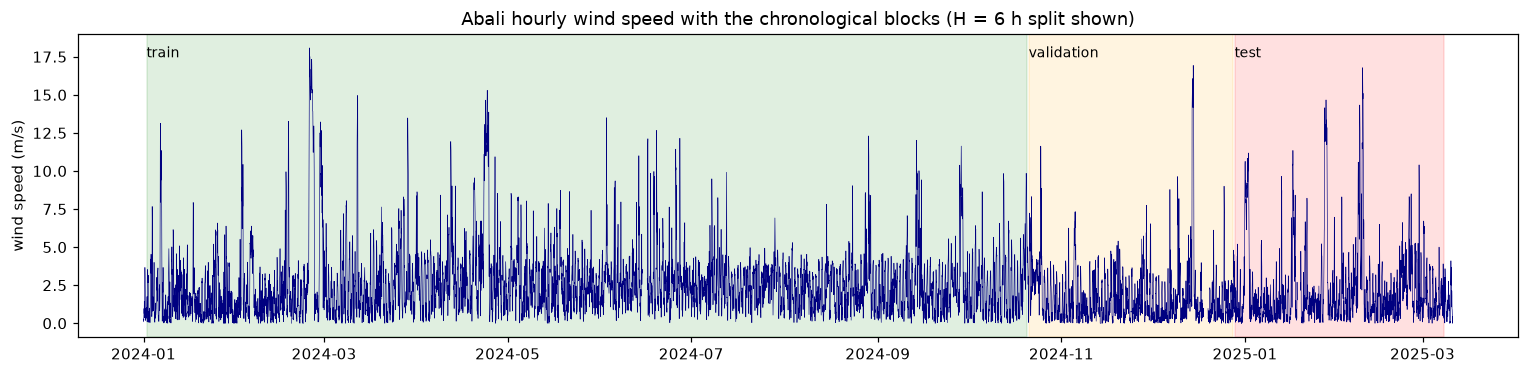

Figure 1 caption draft:
  Hourly mean wind speed at Abali for 2024-01-01 to 2025-03-10 (10,440 hourly
  values, 111 missing hours left as gaps). Shading marks the chronological
  train / validation / test blocks used for the H = 6 h experiment, with a
  purge gap of 6 hours at each boundary.


In [7]:
if OPEN_TEST_BLOCK:
    # ---- Figure 1: data overview with the block boundaries -----------------------
    fig, ax = plt.subplots(figsize=(14, 3.5))
    ax.plot(hourly.index, hourly['wind_speed_ms'], lw=0.4, color='navy')
    H0 = 6
    times = PIPELINE[H0]['split_times']
    for label, (a, b) in times.items():
        ax.axvspan(a, b, alpha=0.12, color={'train': 'green', 'validation': 'orange', 'test': 'red'}[label])
        ax.text(a, ax.get_ylim()[1] * 0.92, label, fontsize=9)
    ax.set_ylabel('wind speed (m/s)')
    ax.set_title('Abali hourly wind speed with the chronological blocks (H = {} h split shown)'.format(H0))
    plt.tight_layout()
    plt.show()

    print('Figure 1 caption draft:')
    print('  Hourly mean wind speed at Abali for 2024-01-01 to 2025-03-10 (10,440 hourly')
    print('  values, 111 missing hours left as gaps). Shading marks the chronological')
    print('  train / validation / test blocks used for the H = 6 h experiment, with a')
    print('  purge gap of 6 hours at each boundary.')
else:
    print('test block not opened: figure 1 would be produced here')

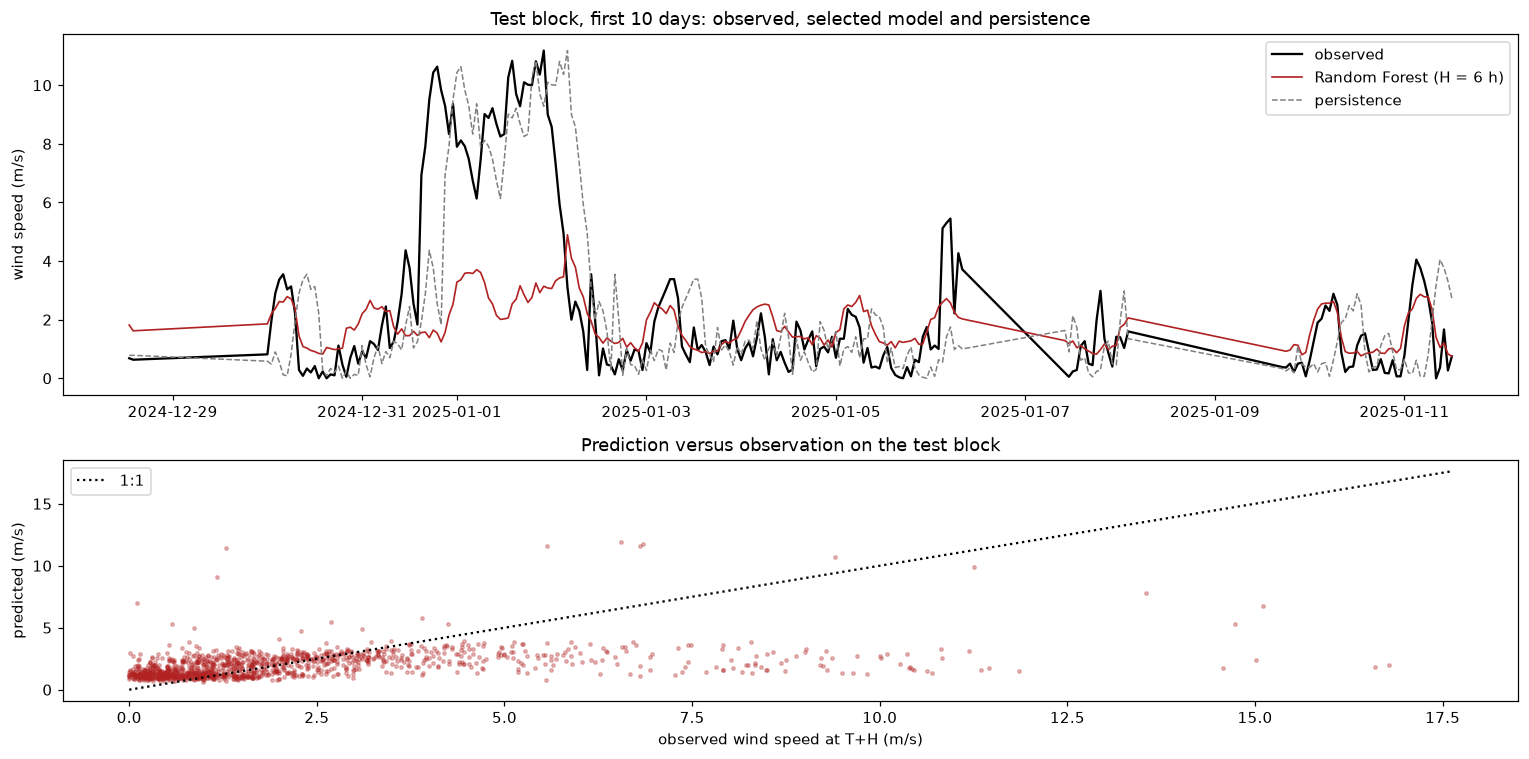

Figure 2 caption draft:
  Upper panel: observed hourly wind speed on the test block (first 10 days)
  with the H = 6 h forecast of the Random Forest model and the persistence baseline.
  Lower panel: forecast versus observed for the whole test block,
  MAE = 1.31 m/s, RMSE = 2.19 m/s, R2 = 0.15. The systematic
  under-prediction of strong winds is visible as flattening below the 1:1 line.


In [8]:
if OPEN_TEST_BLOCK:
    # ---- Figure 2: example forecast on the test block ----------------------------
    H_SHOW = 6
    P = PIPELINE[H_SHOW]
    chosen = SELECTION[H_SHOW]
    truth = P['test_truth']
    pred = pd.Series(P['test'][chosen]['pred'], index=P['test_origin'])
    pers = pd.Series(P['test']['Persistence']['pred'], index=P['test_origin'])

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={'height_ratios': [3, 2]})
    zoom = slice(0, 24 * 10)
    axes[0].plot(truth.index[zoom], truth.values[zoom], color='black', lw=1.5, label='observed')
    axes[0].plot(pred.index[zoom], pred.values[zoom], color='firebrick', lw=1.1, label='{} (H = {} h)'.format(chosen, H_SHOW))
    axes[0].plot(pers.index[zoom], pers.values[zoom], color='grey', lw=1.0, ls='--', label='persistence')
    axes[0].set_ylabel('wind speed (m/s)')
    axes[0].set_title('Test block, first 10 days: observed, selected model and persistence')
    axes[0].legend()

    axes[1].scatter(truth.values, pred.values, s=5, alpha=0.3, color='firebrick')
    lim = [0, max(truth.max(), pred.max()) * 1.05]
    axes[1].plot(lim, lim, ls=':', color='black', label='1:1')
    axes[1].set_xlabel('observed wind speed at T+H (m/s)')
    axes[1].set_ylabel('predicted (m/s)')
    axes[1].set_title('Prediction versus observation on the test block')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    sel = TEST_SCORE[(TEST_SCORE['horizon_h'] == H_SHOW) & (TEST_SCORE['role'] == 'selected')].iloc[0]
    print('Figure 2 caption draft:')
    print('  Upper panel: observed hourly wind speed on the test block (first 10 days)')
    print('  with the H = {} h forecast of the {} model and the persistence baseline.'.format(H_SHOW, chosen))
    print('  Lower panel: forecast versus observed for the whole test block,')
    print('  MAE = {:.2f} m/s, RMSE = {:.2f} m/s, R2 = {:.2f}. The systematic'.format(sel['test_MAE'], sel['test_RMSE'], sel['test_R2']))
    print('  under-prediction of strong winds is visible as flattening below the 1:1 line.')

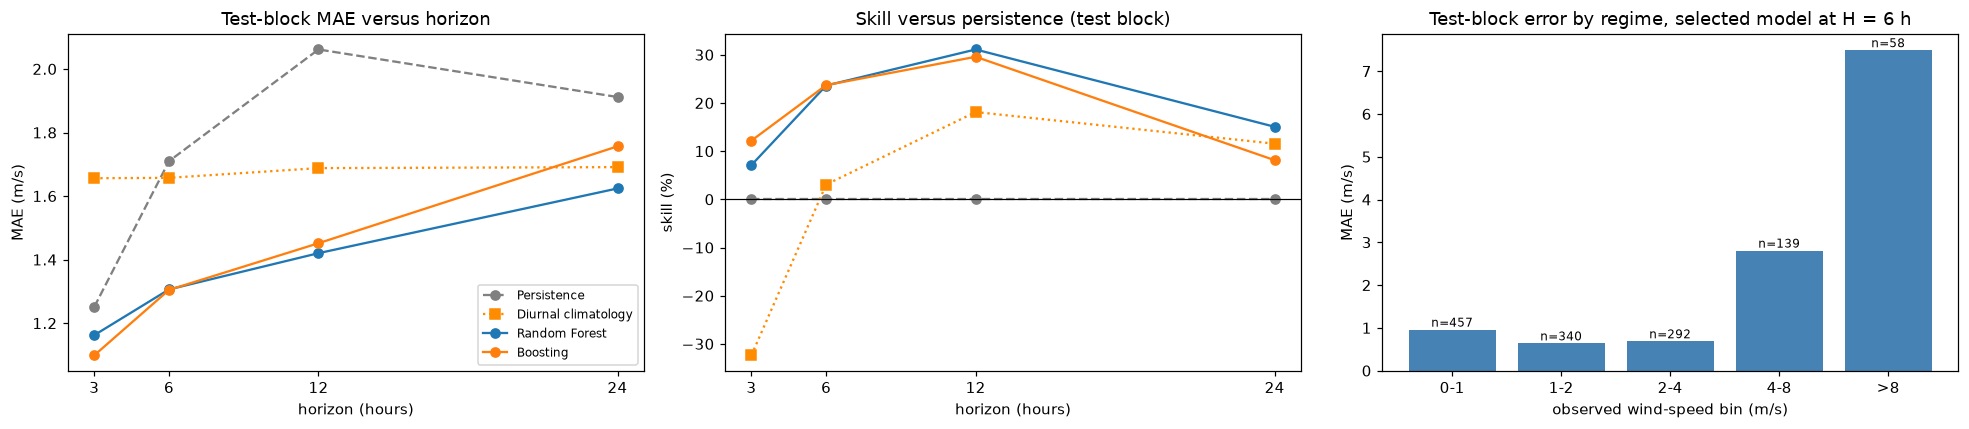

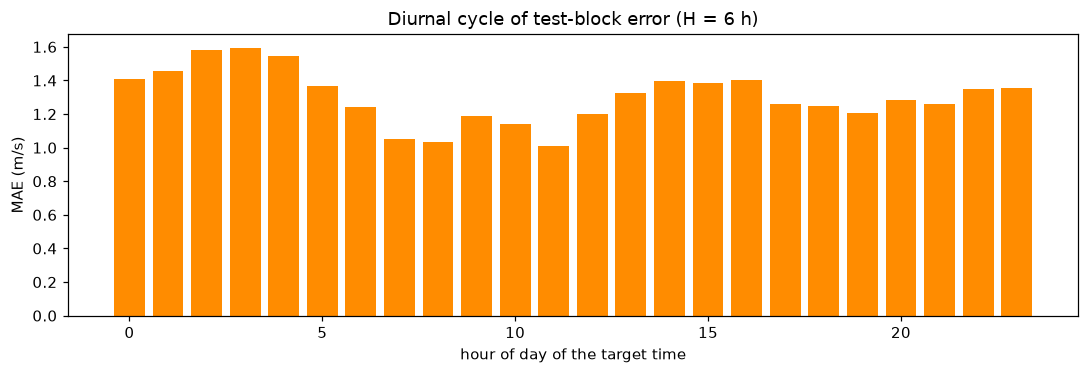

In [9]:
if OPEN_TEST_BLOCK:
    # ---- Figures 3-5: skill by horizon, error by regime, error by hour ----------
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for name in CANDIDATES:
        sel = TEST_SCORE[TEST_SCORE['model'] == name]
        style = dict(marker='o', ls='--', color='grey') if name == 'Persistence' else (
            dict(marker='s', ls=':', color='darkorange') if name == 'Diurnal climatology' else dict(marker='o'))
        axes[0].plot(sel['horizon_h'], sel['test_MAE'], label=name, **style)
        axes[1].plot(sel['horizon_h'], 100 * sel['skill_vs_persistence_test'], label=name, **style)
    axes[0].set_title('Test-block MAE versus horizon')
    axes[0].set_ylabel('MAE (m/s)')
    axes[0].set_xlabel('horizon (hours)')
    axes[0].set_xticks(HORIZONS)
    axes[0].legend(fontsize=8)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('Skill versus persistence (test block)')
    axes[1].set_ylabel('skill (%)')
    axes[1].set_xlabel('horizon (hours)')
    axes[1].set_xticks(HORIZONS)

    H_REG = 6
    rg = BREAKDOWNS[H_REG]['regime']
    axes[2].bar(rg.index.astype(str), rg['MAE'], color='steelblue')
    axes[2].set_xlabel('observed wind-speed bin (m/s)')
    axes[2].set_ylabel('MAE (m/s)')
    axes[2].set_title('Test-block error by regime, selected model at H = {} h'.format(H_REG))
    for k, (idx, row) in enumerate(rg.iterrows()):
        axes[2].text(k, row['MAE'], 'n={}'.format(int(row['n'])), ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 3.5))
    hr = BREAKDOWNS[H_REG]['hour']
    ax.bar(hr.index, hr['MAE'], color='darkorange')
    ax.set_xlabel('hour of day of the target time')
    ax.set_ylabel('MAE (m/s)')
    ax.set_title('Diurnal cycle of test-block error (H = {} h)'.format(H_REG))
    plt.tight_layout()
    plt.show()
else:
    print('test block not opened: figures 3-5 would be produced here')

---

## 6. Serialising the model *without* writing a file

Reproducibility asks a simple question: *if I give someone your model, do they get the same predictions?* Normally you would save it with `joblib.dump(model, 'model.joblib')`. This course deliberately writes nothing to disk - so we serialise into an in-memory buffer instead, reload it, and compare predictions. The check is identical; only the destination differs.

```python
buffer = io.BytesIO()
joblib.dump(model, buffer)
buffer.seek(0)
reloaded = joblib.load(buffer)
assert np.allclose(model.predict(X), reloaded.predict(X))
```

What the round-trip proves: the fitted object contains everything needed to predict. What it does **not** prove: that the *pipeline* is reproducible. That requires the seed, the library versions, the split definition and the feature recipe - all of which belong in your report and in a small environment file.

In [10]:
if OPEN_TEST_BLOCK:
    H_RT = 24
    P = PIPELINE[H_RT]
    chosen = SELECTION[H_RT]

    if chosen in ('Random Forest', 'Boosting'):
        # rebuild the final training set exactly as run_pipeline did
        X, y = build_horizon_dataset(hourly, H_RT)
        tr, va, te = chronological_split(len(y), gap=H_RT)
        cols = select_features(X.iloc[tr], y.iloc[tr])
        X_final = pd.concat([X[cols].iloc[tr], X[cols].iloc[va]])
        y_final = pd.concat([y.iloc[tr], y.iloc[va]])
        X_te = X[cols].iloc[te]

        model = rf_factory() if chosen == 'Random Forest' else booster_factory()
        model.fit(X_final, y_final)

        buffer = io.BytesIO()
        joblib.dump(model, buffer)
        size_kb = buffer.tell() / 1024.0
        buffer.seek(0)
        reloaded = joblib.load(buffer)

        same = np.allclose(model.predict(X_te), reloaded.predict(X_te))
        print('round-trip check for the selected model at H = {} h:'.format(H_RT))
        print('  model                 :', chosen)
        print('  serialised size       : {:.0f} KB (in memory, nothing written to disk)'.format(size_kb))
        print('  predictions identical :', bool(same))
        assert same, 'the reloaded model does not reproduce the predictions'
        print()
        print('If this assertion ever fails, the model object depends on something')
        print('outside itself (a global, a random state, a library detail). Fix that')
        print('before publishing a forecast.')
        del model, reloaded
        buffer.close()
        gc.collect()
    else:
        print('the selected model at H = {} h is the baseline "{}": nothing to serialise.'.format(H_RT, chosen))
        print('A baseline is reproduced by its definition, which is exactly why it is a')
        print('good baseline.')

round-trip check for the selected model at H = 24 h:
  model                 : Boosting
  serialised size       : 839 KB (in memory, nothing written to disk)
  predictions identical : True

If this assertion ever fails, the model object depends on something
outside itself (a global, a random state, a library detail). Fix that
before publishing a forecast.


---

## 7. Limitations

Write these as a numbered list in your report. Each one should be specific enough that a reader knows exactly what is and is not supported by your results.

1. **One station, one year.** `data/raw/abali.xlsx` covers 2024-01-01 to 2025-03-10. Seasonal conclusions rest on roughly one annual cycle, and the test block covers only winter. Nothing here establishes behaviour for other years or other stations.
2. **Local predictors only.** All features come from the station itself. There is no large-scale or remote-sensing input, so any event not yet visible at the station is unforecastable by construction. This is the dominant limitation at 12-24 h.
3. **No extrapolation.** Tree ensembles predict within the range of the training targets. Strong-wind hours are systematically under-forecast, and the model cannot represent an event stronger than its training maximum.
4. **Deterministic forecasts only.** One number per hour, with no uncertainty. The residual analysis (Session 6) shows heteroscedastic errors, so an interval forecast is the natural next step.
5. **Hourly resolution.** Sub-hourly gusts are not modelled, and the hourly mean smooths extremes.
6. **Gap handling.** Short auxiliary gaps are interpolated; the target is never filled. Missing target hours are removed, which biases the sample slightly towards periods with continuous power and telemetry.
7. **Selection uncertainty.** The final model was chosen on a single-season validation block, and Session 5 showed fold-to-fold dispersion of the same order as the differences between models.
8. **No operational latency budget.** Fit times are reported, but the pipeline was never tested under an operational schedule.

A useful test of a limitations section: for each item, can you point to the figure or table that would change if the limitation were removed? If not, either make it specific or delete it.

---

## 8. Structure of a geoscience machine-learning report

| Section | Content | Typical length |
|---|---|---|
| Title and abstract | the question, the data, the method, the headline skill, the main limitation | 150-250 words |
| 1. Introduction | why wind at this station matters; what is known; the gap; the objective | 1 page |
| 2. Data | station, period, resolution, sensor details, missingness, cleaning decisions, block composition | 0.5-1 page |
| 3. Methods | target definition, features and why, split with purge, baselines, models, hyper-parameter protocol, metrics and their units | 1-2 pages |
| 4. Results | validation scoreboard; test scoreboard with baselines; skill-versus-horizon figure; example forecast; regime breakdown | 1.5-2 pages |
| 5. Discussion | what the model learned; where it fails and why; comparison with the literature; limitations | 1-1.5 pages |
| 6. Conclusions | three sentences: what was shown, what it is worth, what next | 0.25 page |
| Data and code availability | exact file, exact versions, exact seeds | short |
| AI-use statement | what was assisted and what was verified | short |
| References | baseline literature, station documentation, ML methods | as needed |

### The four questions every reviewer asks

1. **Is the split honest?** Be ready with the purge gap, the block dates, and the shuffled-split counterexample from Session 2.
2. **Did you beat a real baseline?** Have persistence *and* the diurnal climatology in the same table at every horizon.
3. **How large is the uncertainty?** Report fold dispersion, the validation-to-test change, and the residual spread - not just a mean MAE.
4. **Where does it break?** The regime breakdown and the flattening scatter are the answers. A model with a stated failure mode is more credible than one with a suspiciously uniform score.

### Presenting it in one slide

```
Title:  Wind-speed forecasting at Abali, 3-24 h ahead
One figure:  skill versus horizon with both baselines, test block
One table:   4 rows x (MAE, RMSE, skill) for the selected model per horizon
One sentence: 'A random forest using station observations reaches MAE 1.0-1.4 m/s and
               beats persistence at 3-12 h, but does not beat a diurnal climatology at
               24 h, where forecasts are dominated by the cycle rather than by memory.'
One caveat:   'One year, one station, winter test block, no large-scale predictors.'
```

The sentence in that slide is the deliverable of the entire course: a quantitative, falsifiable, physically meaningful claim.

---

## 9. Reproducibility package

A reader must be able to reproduce your numbers without asking you anything. The minimum package:

| Item | Example for this project |
|---|---|
| Data | `data/raw/abali.xlsx` (checksum it and state the row count) |
| Environment | `Python 3.13, pandas 2.3, numpy 2.5, scikit-learn 1.7, lightgbm 4.7` |
| Seeds | `SEED = 42` for models and samplers |
| Split definition | row-index fractions 70/15/15 with a purge gap of `H` hours, and the resulting dates |
| Cleaning decisions | sentinels and range checks to NaN; short-gap interpolation for auxiliary variables; target never filled |
| Feature recipe | the feature list, exported as text (not as a pickle) |
| Metrics | definitions in m/s, with the baseline values |
| Toggles | `QUICK_MODE`, `N_TREES`, `N_JOBS` |
| AI use | the statement described in Session 6 |

**A habit that saves weeks:** print the manifest at the end of every run (the last cell of every notebook in this course does exactly that) and paste it into an appendix. When a number changes three months later, the manifest tells you which decision changed.

In [11]:
# The decision log: one row per scientific choice made in the project.
DECISION_LOG = [
    {'decision': 'hourly resolution', 'reason': 'native forecasting resolution; 10-minute records averaged', 'alternative': 'keep 10-minute data'},
    {'decision': 'gaps kept as NaN on a regular grid', 'reason': 'lag alignment must stay correct across outages', 'alternative': 'let resample drop empty hours'},
    {'decision': 'target never interpolated', 'reason': 'interpolating the target fabricates the quantity being predicted', 'alternative': 'fill target gaps'},
    {'decision': 'sentinel and range checks to NaN', 'reason': '-99999 humidity and impossible values are instrument failures', 'alternative': 'keep raw values'},
    {'decision': 'strictly-past rolling windows (shift(1))', 'reason': 'removes any argument about availability at the forecast origin', 'alternative': 'include the current hour'},
    {'decision': 'wind direction as sin/cos', 'reason': 'direction is circular; degrees impose a false 359-vs-1 gap', 'alternative': 'raw degrees'},
    {'decision': 'chronological 70/15/15 with purge gap H', 'reason': 'no future information and no target-window overlap', 'alternative': 'random split (invalid), or no purge'},
    {'decision': 'feature selection fitted on the training block only', 'reason': 'selection statistics must not see validation or test', 'alternative': 'select on all data (leakage)'},
    {'decision': 'time-aware cross-validation with a gap', 'reason': 'tuning needs several honest folds', 'alternative': 'shuffled K-fold (invalid)'},
    {'decision': 'test block opened once, after selection was frozen', 'reason': 'preserves it as an honest estimate', 'alternative': 'tune on test (destroys the estimate)'},
    {'decision': 'tie-break in favour of the simpler model within 0.05 m/s', 'reason': 'validation differences below that threshold are not reproducible', 'alternative': 'always take the lowest MAE'},
]
print(pd.DataFrame(DECISION_LOG).to_string(index=False))
print()
print('Every row is a sentence you can defend in review. This table is your methods')
print('section, and it is also the checklist for a reader who wants to reuse your work.')

                                                decision                                                           reason                          alternative
                                       hourly resolution        native forecasting resolution; 10-minute records averaged                  keep 10-minute data
                      gaps kept as NaN on a regular grid                   lag alignment must stay correct across outages        let resample drop empty hours
                               target never interpolated interpolating the target fabricates the quantity being predicted                     fill target gaps
                        sentinel and range checks to NaN    -99999 humidity and impossible values are instrument failures                      keep raw values
                strictly-past rolling windows (shift(1))   removes any argument about availability at the forecast origin             include the current hour
                               wind direction 

---

## 10. Common pitfalls in the final stage

**Pitfall 1 - tuning after seeing the test block.**  
The most damaging and most common. Freeze the selection in writing (section 3) before pressing Shift+Enter on the test cell.

**Pitfall 2 - reporting only the selected model on test.**  
Include the baselines *and* the non-selected candidates. The reader needs to see that your selection rule was applied, not that a single model was tried.

**Pitfall 3 - forgetting to retrain on train+validation.**  
Deploying a model fitted on 70 % of the data when 85 % was available, and validating a different model from the one you describe, is a genuine (if common) inconsistency. State which data the final model used.

**Pitfall 4 - hiding the validation-to-test gap.**  
Report both numbers and attribute the difference to its mechanism. A gap you explain is science; a gap you omit looks like an error.

**Pitfall 5 - a figure with no caption information.**  
Every figure needs the period, the horizon, the model and the reference in its caption. Assume the reader starts at the figure.

**Pitfall 6 - limitations as a formality.**  
A limitations section that could have been written before the analysis is worthless. Each item must connect to a number or a figure.

**Pitfall 7 - claiming physical insight from feature importance.**  
The model relies on the current wind speed because the wind is autocorrelated. That is an artefact of the data structure as much as a discovery about the atmosphere.

**Pitfall 8 - no manifest, no versions, no seeds.**  
Six months later you will not remember which run produced the table. The manifest is five seconds of insurance.

---

## 11. AI-assisted workflow for the final stage

### 11.1 Prompts that help you write the report

| Goal | Prompt |
|---|---|
| structure | 'Given these results and limitations, propose a section-by-section outline for a 6-page geoscience methods paper on station wind forecasting. List what must appear in methods versus results.' |
| consistency check | 'Here is my results table and here is the paragraph describing it. List every number in the text that does not match the table, and every claim that the table does not support.' |
| reviewer simulation | 'Act as a hostile reviewer of a wind-forecasting paper with one year of data from one station. Ask the five hardest questions you can, with the evidence you would demand for each.' |
| abstract tightening | 'Rewrite this abstract to 180 words, keeping the numbers identical and removing every adjective that the data do not support.' |

### 11.2 The verification habit that matters most

Ask the assistant to **quote the source of every factual claim**: a line of your code, a table cell, or a reference. Anything it cannot source is either wrong or unverifiable, and both must go. This single rule catches most of the problems described in Session 6.

### 11.3 Never delegate these four things

1. **The problem definition.** Only you know what decision the forecast should inform.
2. **The split.** Leakage is invisible to an assistant that does not know your data's time structure.
3. **The physical interpretation.** Plausible-sounding mechanisms are the assistant's most convincing failure mode.
4. **The limitations.** They are the part of the work that demonstrates you understand what you did.

### 11.4 A final review prompt

```
Here is my full pipeline as a single script, my validation table and my test table.
Check, in this order:
  (1) every use of a timestamp, shift, rolling window or split;
  (2) the purge gap and the block boundaries;
  (3) whether the final model was trained on the rows I claim;
  (4) whether every reported number is reproducible from the code as written;
  (5) any claim in the text that the tables do not support.
Return a table: location | issue | severity | minimal fix. Do not rewrite anything;
I want the list of problems, not a new script.
```

The instruction 'do not rewrite anything' matters: your goal at this stage is a critique, not a second opinion that you then have to re-verify from scratch.

---

## 12. Exercises

### Level 1 - understanding

1. Why must the test block be used exactly once?
2. Why is it legitimate to retrain the final model on train + validation, but not to *select* it there?
3. Name the four comparisons that must appear in the results table.
4. What does an in-memory `joblib` round-trip prove, and what does it not prove?

### Level 2 - implementation

5. Produce the full pipeline for `H = 1, 2, 48` h and state where the skill versus persistence becomes negative.
6. Add the SVR from Session 3 as a fifth candidate and re-run the selection. Does it change? (Mind the runtime.)
7. Add a residual-based error estimate: report the mean and the 90th percentile of `|error|` on the test block, and a simple interval of +/- 2 x residual std.
8. Write the manifest cell so that it also emits a one-paragraph 'methods summary' sentence that can be pasted into a paper.
9. Re-run the whole pipeline with `OPEN_TEST_BLOCK = False` and confirm that everything except the test scoreboard still executes.

### Level 3 - reasoning

10. Your test MAE is 25 % worse than validation for every model. List three explanations and the diagnostic that separates them.
11. A reviewer says 'a random forest is not a forecasting model'. Write a three-sentence response.
12. The selected model differs between validation and test for two of four horizons. What does that tell you about the size of your validation block, and what would you change in the next study?
13. You must deliver an operational forecast tomorrow with what you have built. Describe the exact procedure, including how you would monitor its performance and when you would retrain.

### Level 4 - the project deliverable

14. **Produce the final report.** Six sections, five figures, the decision log, the limitations list, the reproducibility manifest and the AI-use statement. Target 6 pages, including figures.
15. **Produce the one-slide summary** described in section 8, and present it in three minutes to the class. Expect the four reviewer questions.
16. **Write the handover note.** Half a page for the engineer who will run this operationally: how to install the environment, how to run the pipeline, what to check in the output, and what would indicate that the model has gone stale.

---

## 13. Reproducibility notes for the final project

- **One source of truth:** `data/raw/abali.xlsx`. No cleaned CSV, no second station, no intermediate artefact.
- **Nothing is written to disk** anywhere in this course. Cleaning is in memory, the modelling table is in memory, models are serialised to an in-memory buffer.
- **Seeds:** `SEED = 42` everywhere. A re-run must reproduce the tables.
- **The test block is opened once.** If you re-run this notebook, you have opened it a second time; note that in your report if you re-run after changing anything.
- **Frozen selection.** The selection table was written before the test evaluation and is not revised afterwards.
- **Versions.** Print and record them. XGBoost and LightGBM change defaults between versions; pandas changes time-series behaviour.
- **Toggles to report:** `QUICK_MODE`, `N_TREES`, `N_JOBS`, `OPEN_TEST_BLOCK`, `TIE_TOLERANCE`.
- **The manifest below is the appendix.** Paste it into your report's reproducibility section.

---

## 14. Key takeaways

1. The whole project is one pipeline: clean -> features -> split -> candidates -> select on validation -> freeze -> evaluate once on test.
2. Selection is a scientific decision and must be recorded before the test block is opened, with an explicit tie-break rule.
3. Retrain the final model on train + validation once the selection is frozen; report which data the deployed model used.
4. Report validation and test side by side, with the baselines, and attribute any gap to its mechanism.
5. The regime breakdown and the flattening scatter are the figures that tell the reader where the model fails.
6. A reproducible package is a data path, versions, seeds, a split definition, a feature recipe and a decision log.
7. The one-sentence claim - quantitative, falsifiable, physically meaningful - is the deliverable.

In [12]:
# ===========================================================================
# FINAL VALIDATION CELL - the project manifest
# ===========================================================================
WARNINGS = []
if not OPEN_TEST_BLOCK:
    WARNINGS.append('OPEN_TEST_BLOCK=False: no test evaluation was performed in this run')
if QUICK_MODE:
    WARNINGS.append('QUICK_MODE=True: {} trees; a 300-tree forest will differ slightly'.format(N_TREES))
if not HAS_LGBM:
    WARNINGS.append('lightgbm not installed: boosting provided by another library')
WARNINGS.append('one station, one year of data; the test block covers winter only')
WARNINGS.append('local predictors only: no large-scale or NWP input')
WARNINGS.append('tree ensembles cannot extrapolate beyond the training wind-speed range')
WARNINGS.append('the test block has been opened in this run: do not re-tune after this point')

project_manifest = {
    'notebook': '07_final_project_pipeline_and_report_abali.ipynb',
    'session': 'Session 7 - final project pipeline and report',
    'dataset_used': RAW_PATH + ' (Abali station, 10-minute records averaged to hourly, cleaned in memory)',
    'target_variable': 'hourly mean wind speed at T + H (wind_speed_ms, m/s)',
    'forecast_horizons_hours': HORIZONS,
    'models_used': CANDIDATES,
    'selected_model_per_horizon': {str(H): SELECTION[H] for H in HORIZONS},
    'validation_scheme': 'chronological 70/15/15 with purge gap = H hours',
    'final_training_set': 'train + validation blocks (selection frozen first)',
    'metrics_used': ['MAE (m/s)', 'MSE', 'RMSE (m/s)', 'R2', 'skill_vs_persistence', 'skill_vs_diurnal_climatology'],
    'validation_MAE_selected': {str(H): float(PIPELINE[H]['validation'][SELECTION[H]]['metrics']['MAE']) for H in HORIZONS},
    'test_MAE_selected': ({str(H): float(PIPELINE[H]['test'][SELECTION[H]]['metrics']['MAE']) for H in HORIZONS}
                          if OPEN_TEST_BLOCK else 'test block not opened'),
    'files_written': 'none (cleaning, modelling and model serialisation all in memory)',
    'environment': {'python': sys.version.split()[0], 'pandas': pd.__version__, 'numpy': np.__version__,
                    'joblib': joblib.__version__, 'lightgbm': LGBM_VERSION, 'xgboost': XGB_VERSION},
    'random_seed': SEED,
    'decisions_logged': len(DECISION_LOG),
    'warnings': WARNINGS,
}
print(json.dumps(project_manifest, indent=2, default=str))

{
  "notebook": "07_final_project_pipeline_and_report_abali.ipynb",
  "session": "Session 7 - final project pipeline and report",
  "dataset_used": "../../data/raw/abali.xlsx (Abali station, 10-minute records averaged to hourly, cleaned in memory)",
  "target_variable": "hourly mean wind speed at T + H (wind_speed_ms, m/s)",
  "forecast_horizons_hours": [
    3,
    6,
    12,
    24
  ],
  "models_used": [
    "Persistence",
    "Diurnal climatology",
    "Random Forest",
    "Boosting"
  ],
  "selected_model_per_horizon": {
    "3": "Random Forest",
    "6": "Random Forest",
    "12": "Random Forest",
    "24": "Boosting"
  },
  "validation_scheme": "chronological 70/15/15 with purge gap = H hours",
  "final_training_set": "train + validation blocks (selection frozen first)",
  "metrics_used": [
    "MAE (m/s)",
    "MSE",
    "RMSE (m/s)",
    "R2",
    "skill_vs_persistence",
    "skill_vs_diurnal_climatology"
  ],
  "validation_MAE_selected": {
    "3": 1.0033979372253876,
    "6"

---

## 15. Where to go next

You have a complete, honest, reproducible wind-forecasting study built from one Excel file. Four natural extensions, in increasing order of difficulty:

1. **Probabilistic forecasting.** Predict a distribution instead of a mean: quantile regression (`GradientBoostingRegressor(loss='quantile')`), or a random forest's per-tree spread. Report calibration and a prediction interval. The heteroscedastic residuals of Session 6 guarantee this is worth doing.
2. **Better predictors.** Add reanalysis variables at the station (or neighbouring stations): the large-scale wind speed and the pressure gradient. This attacks the dominant limitation of the current model directly. Evaluate with exactly the same split protocol.
3. **Verification over a full year.** A rolling-origin evaluation across the whole record, stratified by season, so that the seasonal-drift caveat disappears.
4. **Extreme-event handling.** Two-stage modelling: a classifier for 'strong wind in the next H hours' plus a regressor applied only to the flagged hours, with the classification metrics (precision, recall) reported alongside MAE.

Each of those is a paper, and each reuses the pipeline you now have. That is the point of the course: not one notebook, but a repeatable method for turning a geoscience time series into a defensible forecast - and a habit of checking, at every step, whether the evidence supports the claim.